<a href="https://colab.research.google.com/github/skyline554/-1/blob/main/60230449_%EA%B9%80%ED%98%B8%EC%98%811.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# [데이터 로드 코드 - 제공된 양식 그대로 사용]
from sklearn.datasets import fetch_california_housing
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.head())

# --- (1) 전처리 수행 ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X, y 분리
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# 특성 변수 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/테스트 데이터 분리 (80:20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- (2) 세 모델 학습 및 평가 ---
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'LinearRegression': LinearRegression(),
    'Ridge(alpha=1.0)': Ridge(alpha=1.0),
    'Lasso(alpha=0.1)': Lasso(alpha=0.1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"[{name}] 테스트 RMSE: {rmse:.4f}, R2: {r2:.4f}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
[LinearRegression] 테스트 RMSE: 0.7456, R2: 0.5758
[Ridge(alpha=1.0)] 테스트 RMSE: 0.7456, R2: 0.5758
[Lasso(alpha=0.1)] 테스트 RMSE: 0.8243, R2: 0.4814


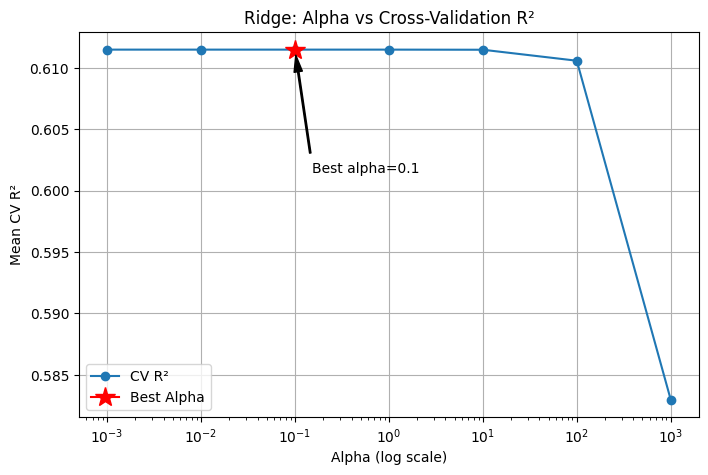

최적 Ridge alpha: 0.1, 해당 CV R²: 0.6115


In [4]:
from sklearn.model_selection import cross_val_score

alphas_ridge = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv_scores = []

# 5-Fold 교차검증 R2 평균 계산
for alpha in alphas_ridge:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    ridge_cv_scores.append(np.mean(scores))

# 최적 alpha 선정
best_idx_ridge = np.argmax(ridge_cv_scores)
best_alpha_ridge = alphas_ridge[best_idx_ridge]
best_r2_ridge = ridge_cv_scores[best_idx_ridge]

# 시각화
plt.figure(figsize=(8, 5))
plt.plot(alphas_ridge, ridge_cv_scores, marker='o', label='CV R²')
plt.xscale('log')
plt.plot(best_alpha_ridge, best_r2_ridge, marker='*', color='red', markersize=15, label='Best Alpha')
plt.annotate(f'Best alpha={best_alpha_ridge}',
             xy=(best_alpha_ridge, best_r2_ridge),
             xytext=(best_alpha_ridge*1.5, best_r2_ridge-0.01),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.title('Ridge: Alpha vs Cross-Validation R²')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV R²')
plt.legend()
plt.grid(True)
plt.show()

print(f"최적 Ridge alpha: {best_alpha_ridge}, 해당 CV R²: {best_r2_ridge:.4f}")

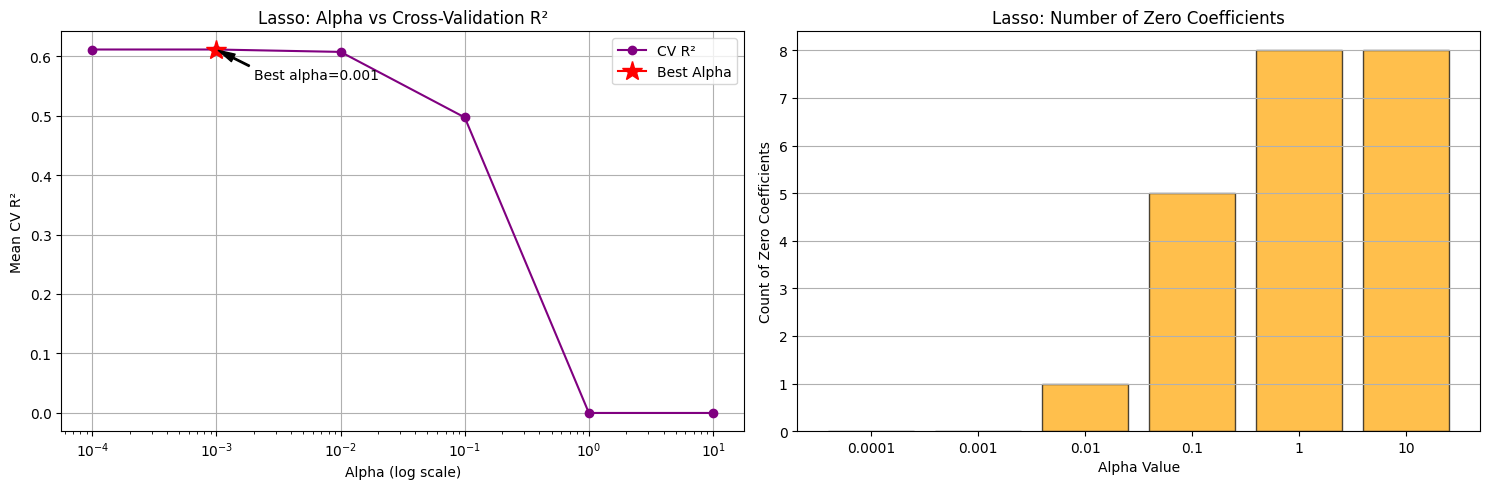

최적 Lasso alpha: 0.001, 해당 CV R²: 0.6115


In [5]:
alphas_lasso = [0.0001, 0.001, 0.01, 0.1, 1, 10]
lasso_cv_scores = []
zero_coef_counts = []

for alpha in alphas_lasso:
    model = Lasso(alpha=alpha)
    # 5-Fold 교차검증 R2
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    lasso_cv_scores.append(np.mean(scores))

    # 희소화된 특성(계수가 0인 개수) 계산
    model.fit(X_train, y_train)
    zero_count = np.sum(model.coef_ == 0)
    zero_coef_counts.append(zero_count)

best_idx_lasso = np.argmax(lasso_cv_scores)
best_alpha_lasso = alphas_lasso[best_idx_lasso]
best_r2_lasso = lasso_cv_scores[best_idx_lasso]

# 1행 2열 서브플롯 구성
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 왼쪽: Alpha vs CV R2
axes[0].plot(alphas_lasso, lasso_cv_scores, marker='o', color='purple', label='CV R²')
axes[0].set_xscale('log')
axes[0].plot(best_alpha_lasso, best_r2_lasso, marker='*', color='red', markersize=15, label='Best Alpha')
axes[0].annotate(f'Best alpha={best_alpha_lasso}',
                 xy=(best_alpha_lasso, best_r2_lasso), xytext=(best_alpha_lasso*2, best_r2_lasso-0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
axes[0].set_title('Lasso: Alpha vs Cross-Validation R²')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Mean CV R²')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: 희소화된 특성 수 막대그래프
# 막대그래프 표현을 위해 x축 간격을 문자열 인덱스로 매핑하거나 width 조절 후 log scale 유지
axes[1].bar([str(a) for a in alphas_lasso], zero_coef_counts, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title('Lasso: Number of Zero Coefficients')
axes[1].set_xlabel('Alpha Value')
axes[1].set_ylabel('Count of Zero Coefficients')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f"최적 Lasso alpha: {best_alpha_lasso}, 해당 CV R²: {best_r2_lasso:.4f}")

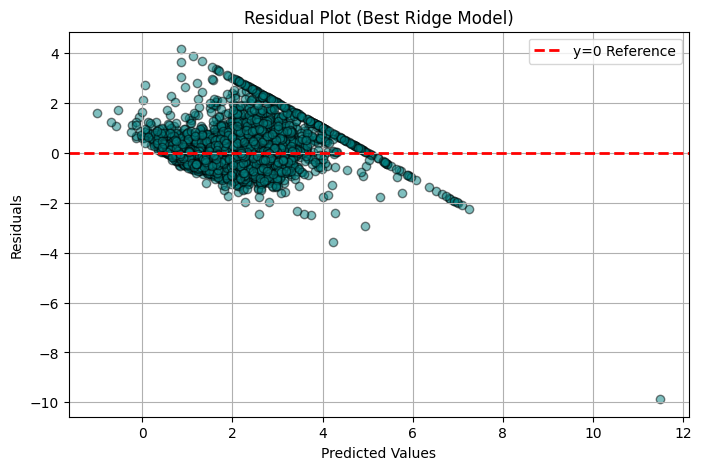

In [6]:
# (3)에서 구한 최적 Ridge 모델 재학습 및 예측
best_ridge = Ridge(alpha=best_alpha_ridge)
best_ridge.fit(X_train, y_train)
y_pred_ridge = best_ridge.predict(X_test)

# 잔차 계산
residuals = y_test - y_pred_ridge

# 잔차 산점도 시각화
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_ridge, residuals, alpha=0.5, color='teal', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='y=0 Reference')
plt.title('Residual Plot (Best Ridge Model)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# [데이터 로드 코드 - 제공된 양식 그대로 사용]
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- (1) 전처리 수행 ---
# 1D 벡터 변환 (784) 및 0~1 범위 정규화
X_train_flat = X_train_raw.reshape(-1, 28*28) / 255.0
X_test_flat = X_test_raw.reshape(-1, 28*28) / 255.0

# 처음 10,000개만 슬라이싱
X_train = X_train_flat[:10000]
y_train = y_train_raw[:10000]
X_test = X_test_flat
y_test = y_test_raw

# --- (2) 로지스틱 회귀 모형 학습 및 평가 ---
# max_iter는 안정적인 수렴을 위해 1000으로 지정합니다.
lr_clf = LogisticRegression(max_iter=1000, random_state=42)
lr_clf.fit(X_train, y_train)

y_pred_lr = lr_clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_lr)
print(f"로지스틱 회귀 분류기 테스트 Accuracy: {test_acc:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
로지스틱 회귀 분류기 테스트 Accuracy: 0.8266


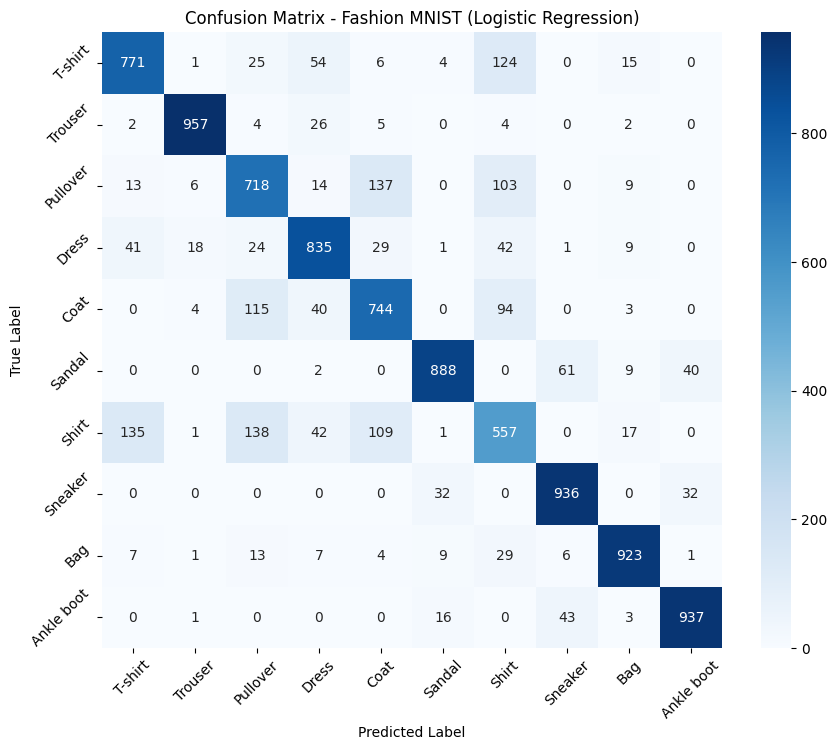

In [8]:
# 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred_lr)

# seaborn heatmap 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fashion MNIST (Logistic Regression)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

/tmp/ipykernel_1098/3601067611.py:15: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1098/3601067611.py:15: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1098/3601067611.py:15: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1098/3601067611.py:15: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/di

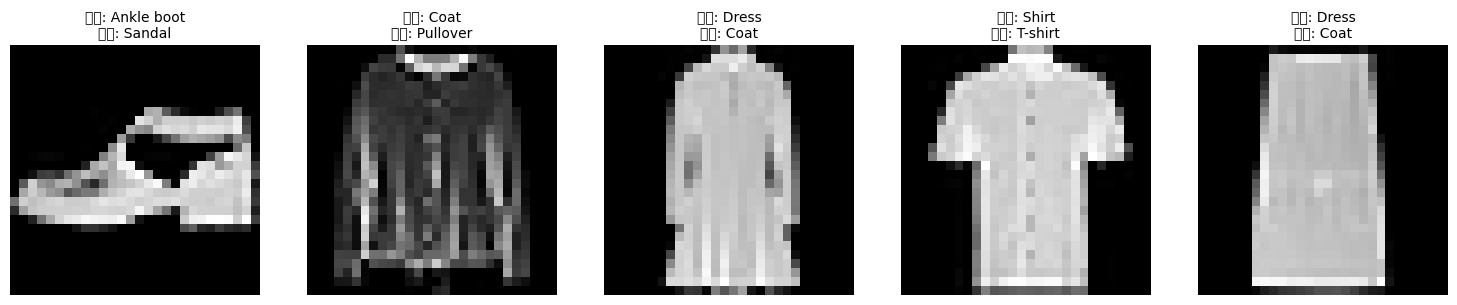

In [9]:
# 예측 오류가 발생한 인덱스 추출
misclassified_idx = np.where(y_test != y_pred_lr)[0]

# 처음 5개 선택 및 이미지 출력
plt.figure(figsize=(15, 3))
for i, idx in enumerate(misclassified_idx[:5]):
    plt.subplot(1, 5, i + 1)
    # 원본 2D 이미지 형태로 복원하여 출력 (X_test_raw 사용 혹은 reshape)
    plt.imshow(X_test_flat[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred_lr[idx]]
    plt.title(f"실제: {true_label}\n예측: {pred_label}", fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
# [데이터 로드 코드 - 제공된 양식 그대로 사용]
from sklearn.datasets import fetch_openml
import pandas as pd, numpy as np

# OpenML Airlines 실제 데이터 로드 (약 1~2분 소요)
data = fetch_openml(data_id=1169, as_frame=True, parser='auto')
df = data.frame.copy()

# --- (1) 전처리 수행 ---
# 결측값 제거
df = df.dropna()

# 범주형 컬럼 지정 및 원-핫 인코딩 수치화
categorical_cols = ['Airline', 'AirportFrom', 'AirportTo']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 만약 수치형 컬럼 중 타겟 변수를 제외하고 변환 타입 에러를 방지하기 위해 전체 데이터타입을 float32로 통일
X = df.drop(columns=['Delay']).astype('float32')
y = df['Delay'].astype('int32')

# 특성 표준화 및 데이터 분할
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler_dl = StandardScaler()
X_scaled = scaler_dl.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# y의 분포 및 비율 출력
class_counts = y.value_counts()
class_proportions = y.value_counts(normalize=True)
print("=== Target (Delay) Distribution ===")
for cls in class_counts.index:
    print(f"Class {cls}: {class_counts[cls]}건 ({class_proportions[cls]*100:.2f}%)")

=== Target (Delay) Distribution ===
Class 0: 299119건 (55.46%)
Class 1: 240264건 (44.54%)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- (2) Sequential 모델 레이어 정의 ---
model_dl = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # 레이어 1 (입력층 shape 전달)
    Dropout(0.3),                                                 # 레이어 2
    Dense(32, activation='relu'),                                 # 레이어 4 (명세서 기준 은닉층)
    Dropout(0.3),                                                 # 레이어 5
    Dense(1, activation='sigmoid')                                # 레이어 6 (출력층)
])

# --- (3) 모델 컴파일 및 조기 종료 학습 설정 ---
model_dl.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# validation 비율 분리: test 대신 validation 데이터 분할 적용 (X_train 내부에서 8:2 분할 연동)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_dl.fit(X_train, y_train,
                       epochs=50, # 적정 탐색 최대 에포크 지정
                       batch_size=512,
                       validation_split=0.2, # train 내에서 validation=0.2 적용
                       callbacks=[early_stopping],
                       verbose=1)

# 실제 조기 종료된 epoch 출력
stopped_epoch = early_stopping.stopped_epoch
if stopped_epoch == 0:
    actual_epochs = len(history.history['loss'])
else:
    actual_epochs = stopped_epoch + 1
print(f"\n[결과] 실제 학습이 종료된 Epoch 수: {actual_epochs}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6168 - loss: 0.6618 - val_accuracy: 0.6476 - val_loss: 0.6269
Epoch 2/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6436 - loss: 0.6328 - val_accuracy: 0.6503 - val_loss: 0.6228
Epoch 3/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6490 - loss: 0.6281 - val_accuracy: 0.6525 - val_loss: 0.6201
Epoch 4/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6509 - loss: 0.6252 - val_accuracy: 0.6542 - val_loss: 0.6186
Epoch 5/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6528 - loss: 0.6239 - val_accuracy: 0.6547 - val_loss: 0.6184
Epoch 6/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6545 - loss: 0.6222 - val_accuracy: 0.6563 - val_loss: 0.6169
Epoch 7/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6555 - loss: 0.6209 - val_accuracy: 0.6565 - val_loss: 0.6165
Epoch 8/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6569 - loss: 0.6197 - val_accuracy:

3372/3372 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
=== 최종 테스트 성능 결과 ===
Accuracy: 0.6610
F1-score(binary): 0.5260

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.65      0.85      0.74     59879
           1       0.70      0.42      0.53     47998

    accuracy                           0.66    107877
   macro avg       0.67      0.64      0.63    107877
weighted avg       0.67      0.66      0.64    107877



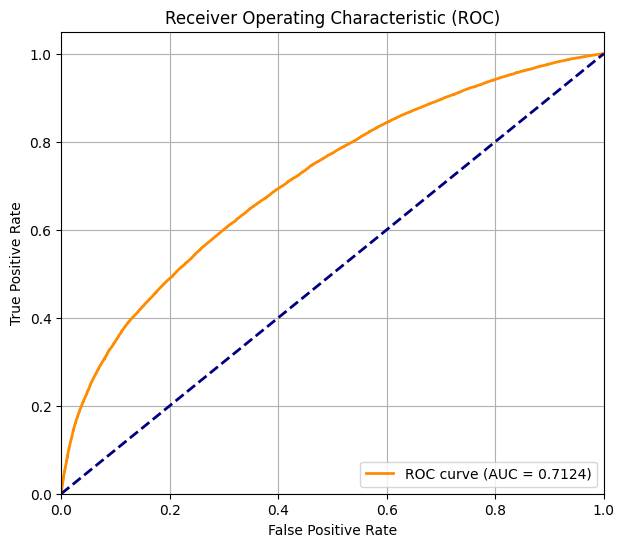

In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, auc

# 예측 확률값 및 클래스 분류
y_pred_prob = model_dl.predict(X_test).ravel()
y_pred_class = (y_pred_prob > 0.5).astype(int)

# 지표 출력
print("=== 최종 테스트 성능 결과 ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_class):.4f}")
print(f"F1-score(binary): {f1_score(y_test, y_pred_class):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_class))

# ROC 및 AUC 계산
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# ROC 곡선 시각화
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# --- 주석문 작성 요구사항 서술 (#) ---
# # [답안 서술] 딥러닝 모델이 단순 로지스틱 회귀보다 이 문제에서 유리한 이유:
# # 해당 데이터셋은 원-핫 인코딩으로 확장된 방대한 범주형 차원과 대규모 샘플 수(약 53만 건)를 가집니다.
# # 로지스틱 회귀는 선형 결합 구조만을 학습하지만, MLP 구조의 딥러닝 모델은 은닉층과 비선형 활성화 함수(ReLU)를 통해
# # 다차원 특성 간의 복잡한 비선형 상호작용 및 고차원적인 패턴을 효과적으로 계층화하여 포착할 수 있어 분류 예측력 측면에서 훨씬 유리합니다.